In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

In [3]:
# Cell 2: Load Data and Initial Exploration
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

In [4]:
# Show data info and first few rows
print(train_df.info())
print(train_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

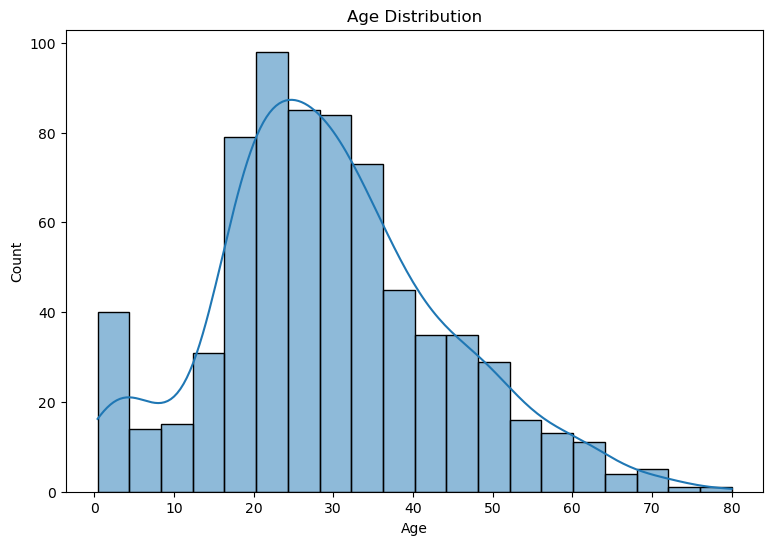

In [5]:
# Cell 3: Visualizations - Age Distribution, Boxplot Age by Class, Pairplot
plt.figure(figsize=(9,6))
sns.histplot(train_df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()


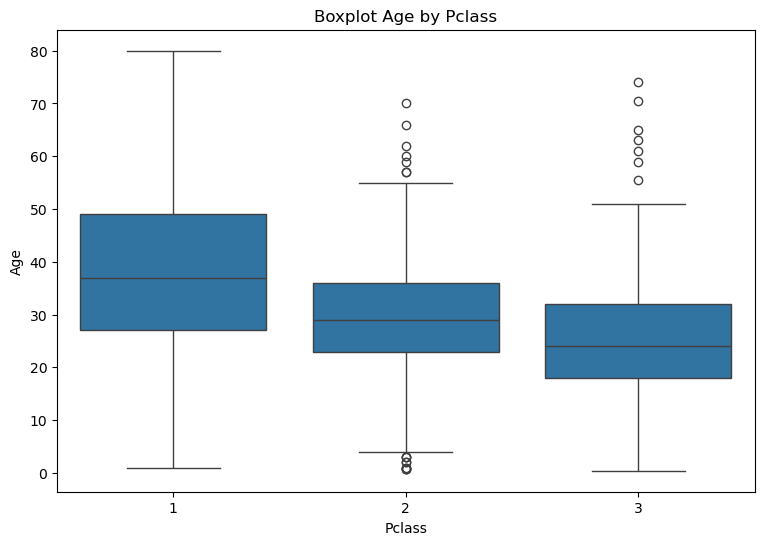

In [6]:
plt.figure(figsize=(9,6))
sns.boxplot(x='Pclass', y='Age', data=train_df)
plt.title('Boxplot Age by Pclass')
plt.show()

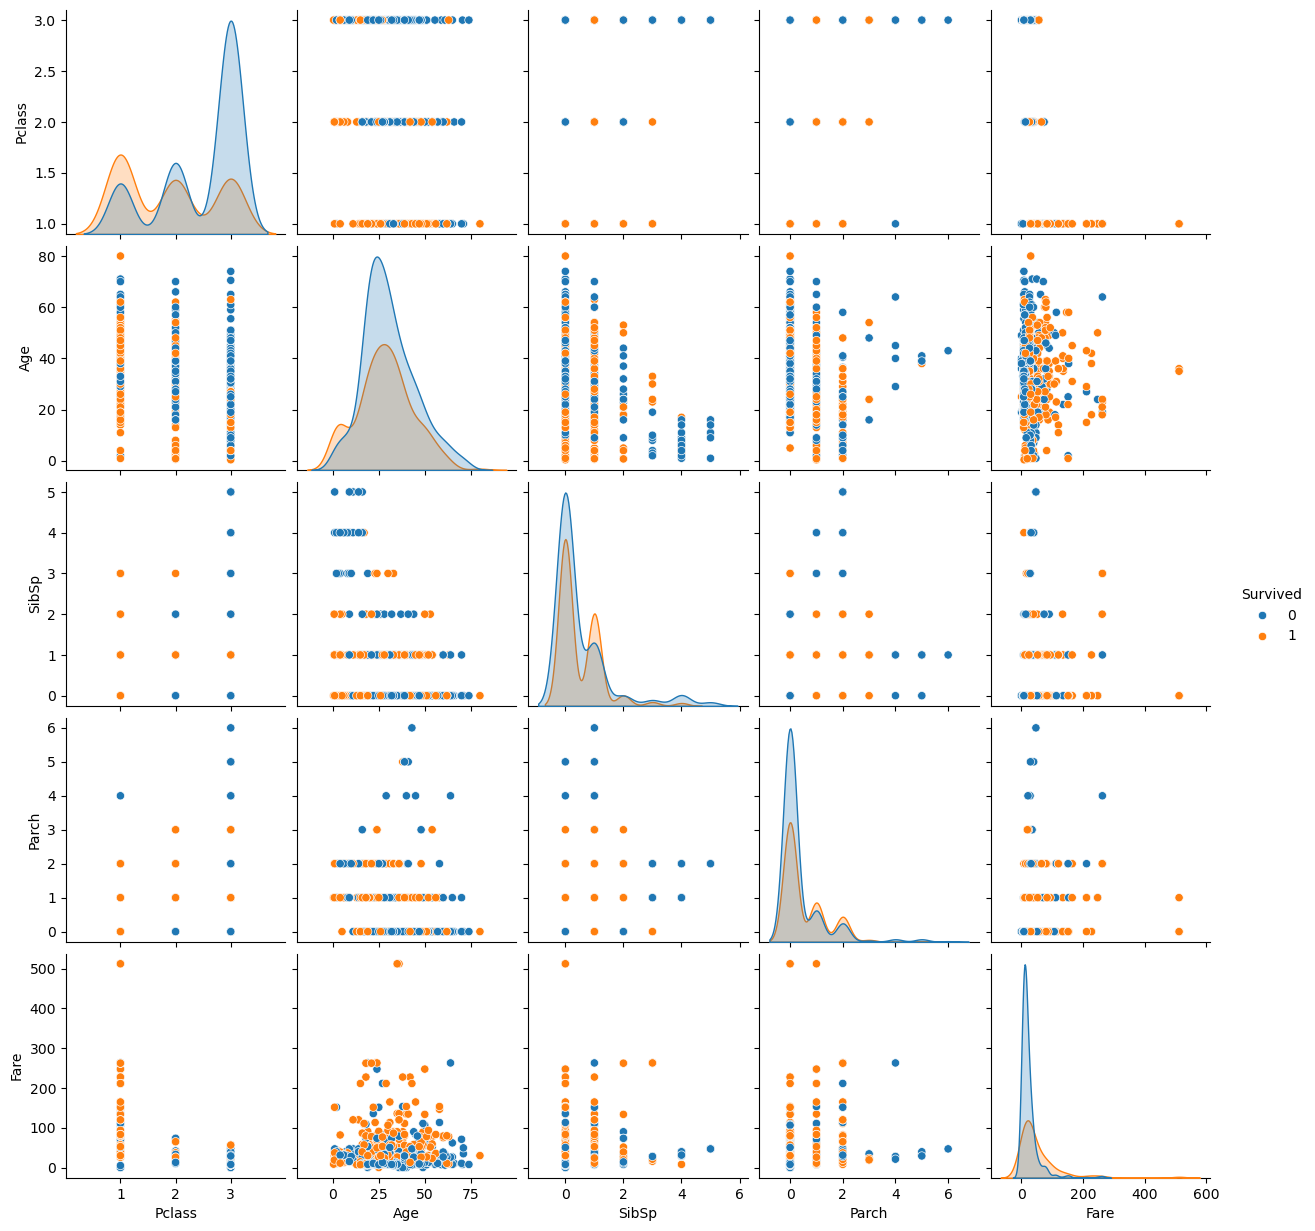

In [7]:

sns.pairplot(train_df[['Survived','Pclass','Age','SibSp','Parch','Fare']].dropna(), hue='Survived')
plt.show()

In [8]:
# Cell 4: Check Missing Values
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Cell 5: Data Preprocessing
# Impute missing Age with median, Embarked with mode, drop irrelevant cols
imputer_age = SimpleImputer(strategy='median')
train_df['Age'] = imputer_age.fit_transform(train_df[['Age']])
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
train_df = train_df.drop(['Cabin','Ticket','Name','PassengerId'], axis=1)

In [10]:
# Encode categorical variables
train_df['Sex'] = LabelEncoder().fit_transform(train_df['Sex'])
train_df['Embarked'] = LabelEncoder().fit_transform(train_df['Embarked'])

In [11]:
# Cell 6: Prepare Training and Validation Data
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [14]:
# Cell 7: Model Building and Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [15]:
# Cell 8: Model Evaluation
preds = model.predict(X_val_scaled)
probs = model.predict_proba(X_val_scaled)[:,1]

In [16]:
print('Accuracy:', accuracy_score(y_val, preds))
print('Precision:', precision_score(y_val, preds))
print('Recall:', recall_score(y_val, preds))
print('F1 Score:', f1_score(y_val, preds))
print('ROC AUC Score:', roc_auc_score(y_val, probs))
print('\nClassification Report:\n', classification_report(y_val, preds))

Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552
ROC AUC Score: 0.8818532818532818

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



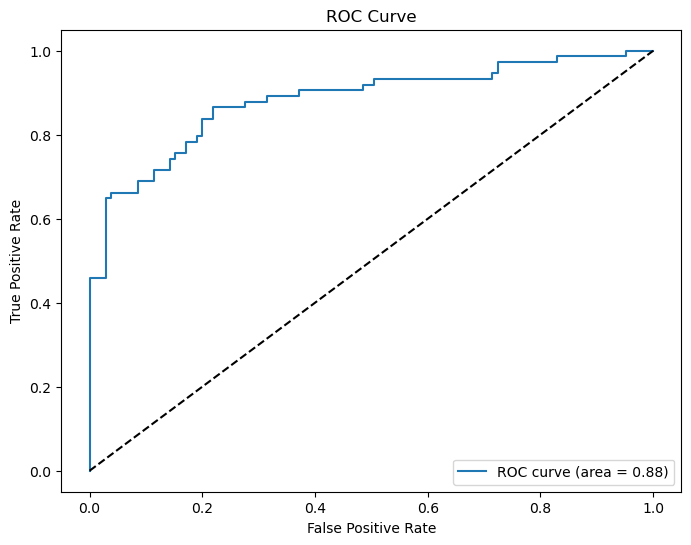

In [17]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(y_val, probs))
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [18]:
# Cell 9: Interpretation of Coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print(coefficients.sort_values(by='Coefficient', ascending=False))

    Feature  Coefficient
5      Fare     0.126216
4     Parch    -0.098292
6  Embarked    -0.170860
3     SibSp    -0.349582
2       Age    -0.395574
0    Pclass    -0.782061
1       Sex    -1.278865
